In [33]:
# Standard library
import os

# Third-party — data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

[Link to Dataset](https://www.kaggle.com/datasets/rohitudageri/credit-card-details)

In [34]:
label_df = pd.read_csv('./Credit_card_label.csv')
data_df = pd.read_csv('./Credit_card.csv')

# concat the two dataframes where the Ind_ID is the same
df = pd.merge(data_df, label_df, on='Ind_ID')
df

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,5028645,F,N,Y,0,NaN,Commercial associate,Higher education,Married,House / apartment,-11957.0,-2182,1,0,0,0,Managers,2,0
1544,5023655,F,N,N,0,225000.0,Commercial associate,Incomplete higher,Single / not married,House / apartment,-10229.0,-1209,1,0,0,0,Accountants,1,0
1545,5115992,M,Y,Y,2,180000.0,Working,Higher education,Married,House / apartment,-13174.0,-2477,1,0,0,0,Managers,4,0
1546,5118219,M,Y,N,0,270000.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-15292.0,-645,1,1,1,0,Drivers,2,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df.columns

Index(['Ind_ID', 'GENDER', 'Car_Owner', 'Propert_Owner', 'CHILDREN',
       'Annual_income', 'Type_Income', 'EDUCATION', 'Marital_status',
       'Housing_type', 'Birthday_count', 'Employed_days', 'Mobile_phone',
       'Work_Phone', 'Phone', 'EMAIL_ID', 'Type_Occupation', 'Family_Members',
       'label'],
      dtype='object')

In [38]:
# lower case all the columns
df.columns = df.columns.str.lower()

# strip the columns of whitespace
df.columns = df.columns.str.strip()

df.columns

Index(['ind_id', 'gender', 'car_owner', 'propert_owner', 'children',
       'annual_income', 'type_income', 'education', 'marital_status',
       'housing_type', 'birthday_count', 'employed_days', 'mobile_phone',
       'work_phone', 'phone', 'email_id', 'type_occupation', 'family_members',
       'label'],
      dtype='object')

In [39]:

df.drop(columns=['ind_id'], inplace=True)

df.head()

,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,type_occupation,family_members,label
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [40]:
df.isnull().sum()

gender               7
car_owner            0
propert_owner        0
children             0
annual_income       23
type_income          0
education            0
marital_status       0
housing_type         0
birthday_count      22
employed_days        0
mobile_phone         0
work_phone           0
phone                0
email_id             0
type_occupation    488
family_members       0
label                0
dtype: int64

Use an Imputer for the missing values

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1541 non-null   object 
 1   car_owner        1548 non-null   object 
 2   propert_owner    1548 non-null   object 
 3   children         1548 non-null   int64  
 4   annual_income    1525 non-null   float64
 5   type_income      1548 non-null   object 
 6   education        1548 non-null   object 
 7   marital_status   1548 non-null   object 
 8   housing_type     1548 non-null   object 
 9   birthday_count   1526 non-null   float64
 10  employed_days    1548 non-null   int64  
 11  mobile_phone     1548 non-null   int64  
 12  work_phone       1548 non-null   int64  
 13  phone            1548 non-null   int64  
 14  email_id         1548 non-null   int64  
 15  type_occupation  1060 non-null   object 
 16  family_members   1548 non-null   int64  
 17  label         

In [42]:
from sklearn.impute import SimpleImputer

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

# create an imputer for the categorical columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
# create an imputer for the numerical columns
numerical_imputer = SimpleImputer(strategy='median')

# fit the imputer on the categorical columns
for col in categorical_cols:
    df[col] = categorical_imputer.fit_transform(df[[col]]).ravel()

# fit the imputer on the numerical columns
for col in numerical_cols:
    df[col] = numerical_imputer.fit_transform(df[[col]]).ravel()

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1548 non-null   object 
 1   car_owner        1548 non-null   object 
 2   propert_owner    1548 non-null   object 
 3   children         1548 non-null   float64
 4   annual_income    1548 non-null   float64
 5   type_income      1548 non-null   object 
 6   education        1548 non-null   object 
 7   marital_status   1548 non-null   object 
 8   housing_type     1548 non-null   object 
 9   birthday_count   1548 non-null   float64
 10  employed_days    1548 non-null   float64
 11  mobile_phone     1548 non-null   float64
 12  work_phone       1548 non-null   float64
 13  phone            1548 non-null   float64
 14  email_id         1548 non-null   float64
 15  type_occupation  1548 non-null   object 
 16  family_members   1548 non-null   float64
 17  label         

In [45]:
df.isna().sum()

gender             0
car_owner          0
propert_owner      0
children           0
annual_income      0
type_income        0
education          0
marital_status     0
housing_type       0
birthday_count     0
employed_days      0
mobile_phone       0
work_phone         0
phone              0
email_id           0
type_occupation    0
family_members     0
label              0
dtype: int64

# EDA

In [46]:
df.describe()

,children,annual_income,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,family_members,label
count,1548.000000,1.548000e+03,1548.000000,1548.000000,1548.0,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,0.412791,1.910294e+05,-16034.958010,59364.689922,1.0,0.208010,0.309432,0.092377,2.161499,0.113049
std,0.776691,1.124483e+05,4199.561035,137808.062701,0.0,0.406015,0.462409,0.289651,0.947772,0.316755
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,1.215000e+05,-19476.000000,-3174.500000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,0.000000,1.665000e+05,-15661.500000,-1565.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12483.000000,-431.750000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,14.000000,1.575000e+06,-7705.000000,365243.000000,1.0,1.000000,1.000000,1.000000,15.000000,1.000000


In [47]:
# helper function to interpret level of skewness
def interpret_skewness(skew_value):
    if skew_value > 1:
        return "highly positively skewed"
    elif skew_value > 0.5:
        return "moderately positively skewed"
    elif skew_value > 0:
        return "slightly positively skewed"
    elif skew_value < -1:
        return "highly negatively skewed"
    elif skew_value < -0.5:
        return "moderately negatively skewed"
    elif skew_value < 0:
        return "slightly negatively skewed"
    else:
        return "symmetrical distribution"

In [50]:
# Get the skewness of the numerical columns
skewness = df[numerical_cols].skew()

skewness_interpretation = skewness.apply(interpret_skewness)

print("Skewness of numerical columns:")
print(skewness)
print("\nInterpretation of skewness:")
print(skewness_interpretation)

Skewness of numerical columns:
children          4.631122
annual_income     3.959453
birthday_count   -0.176124
employed_days     1.770964
mobile_phone      0.000000
work_phone        1.440179
phone             0.825309
email_id          2.818216
family_members    2.232273
label             2.446379
dtype: float64

Interpretation of skewness:
children              highly positively skewed
annual_income         highly positively skewed
birthday_count      slightly negatively skewed
employed_days         highly positively skewed
mobile_phone          symmetrical distribution
work_phone            highly positively skewed
phone             moderately positively skewed
email_id              highly positively skewed
family_members        highly positively skewed
label                 highly positively skewed
dtype: object


We can see that most of the columns has a a highly positively skewed distribution. This is expected as most of the customers will have a low credit limit and a low balance. However, there are some customers who have a high credit limit and a high balance, which is why we see a long tail in the distribution.

Decision: See a Violin Plot for each of the numerical columns to see the distribution of the data and how it relates to the target variable.

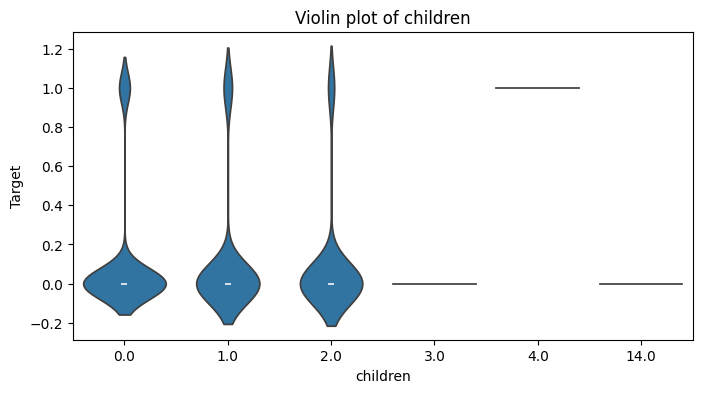

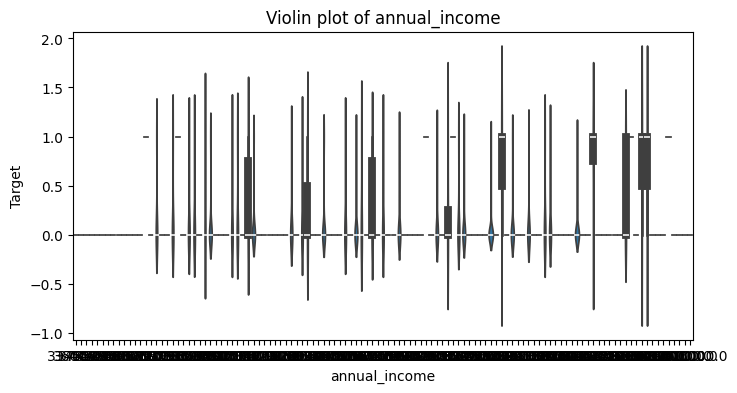

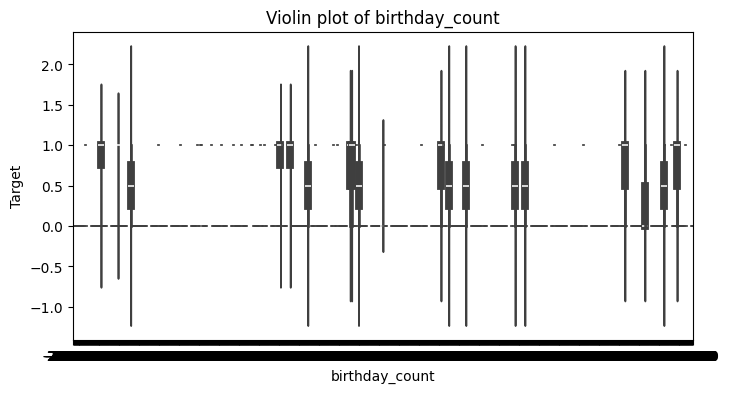

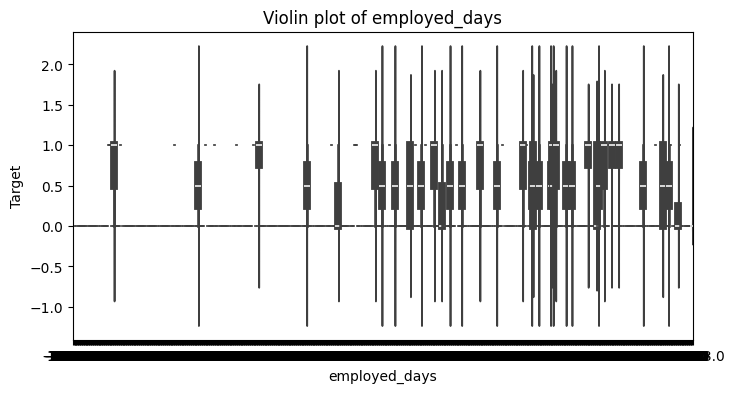

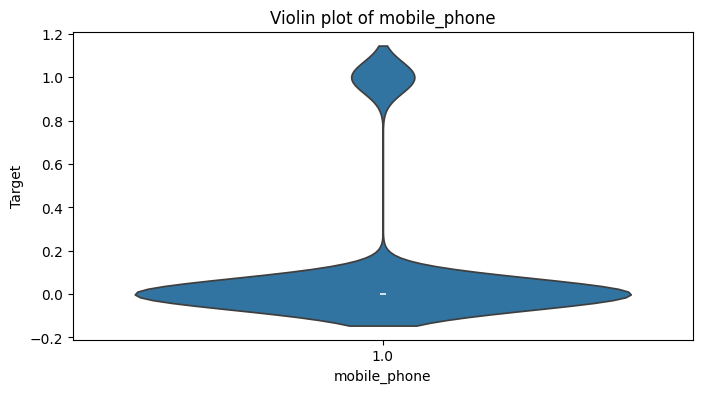

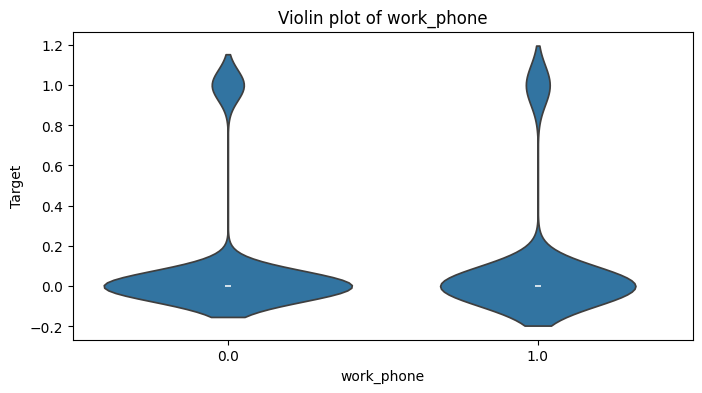

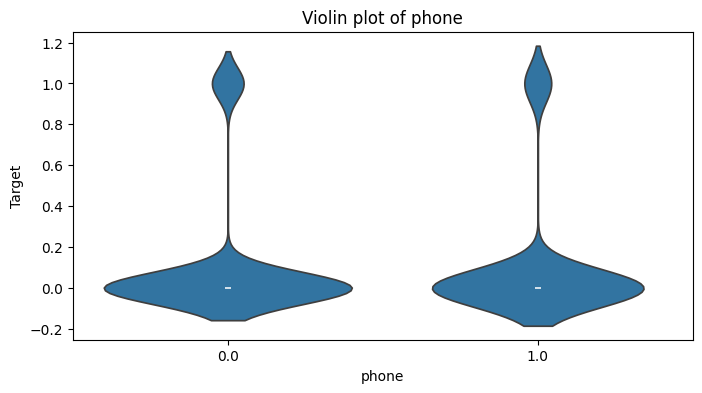

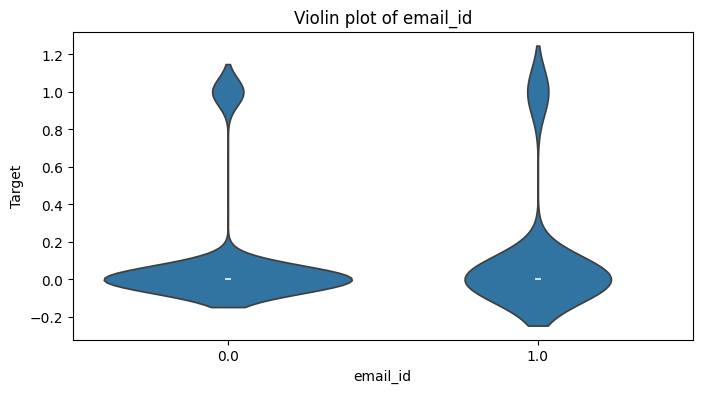

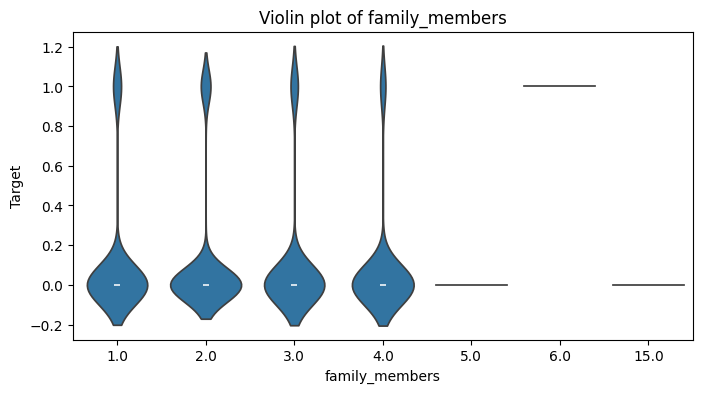

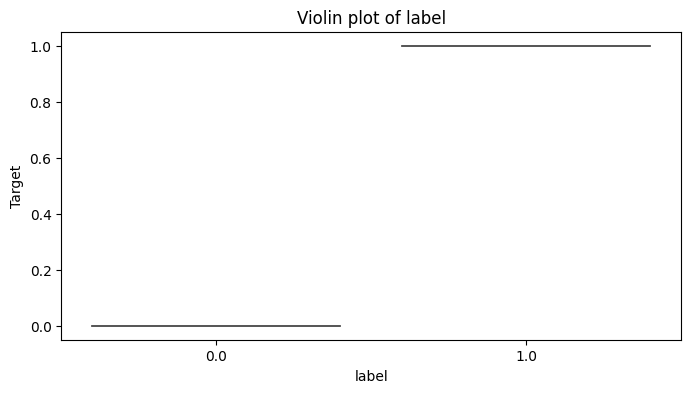

In [ ]:
# Run a Violin Plot for each of the numerical columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x=col, data=df, y="label")
    plt.title(f'Violin plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Target')
    plt.show()